# 4-Class Defect Detection — MobileNetV2 (Full Unfreezing from Phase-1 Checkpoint)

This notebook **reuses the Phase-1 checkpoint** already trained in `4_class_model_MobileNet.ipynb`  
and applies a more aggressive fine-tuning: **all MobileNetV2 layers unfrozen**.

| | Original | This notebook |
|--|---------|---------------|
| Phase 1 | ✅ Trained (50 epochs) | ♻️ **Loaded from checkpoint** |
| Fine-tuning layers | Last 20 | **All 154 MobileNetV2 layers** |
| Fine-tuning epochs | 50 | **100** |
| Fine-tuning LR | 1e-5 | 1e-5 |

**Classes:**

| Label | Class | Source folder |
|-------|-------|---------------|
| 0 | Cracking | `data/Cracking` |
| 1 | Stringing | `data/Stringing` |
| 2 | Warping | `data/Warping` |
| 3 | No_Defect | `data/No_Stringing` |

---
## 1. Imports & Configuration

In [1]:
print(5)

5


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import callbacks

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)

SEED        = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS_FT   = 100
NUM_CLASSES = 4
CLASS_NAMES = ["Cracking", "Stringing", "Warping", "No_Defect"]

# Path to the Phase-1 checkpoint from 4_class_model_MobileNet.ipynb
PHASE1_CKPT = "best_mobilenetv2_4class_phase1.h5"

print(f"TensorFlow: {tf.__version__}")
print(f"GPU       : {tf.config.list_physical_devices('GPU')}")
print(f"Phase-1 checkpoint exists: {os.path.exists(PHASE1_CKPT)}")

2026-05-15 13:57:40.728860: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778849860.777437   55952 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778849860.792720   55952 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-15 13:57:40.896289: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.18.0
GPU       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Phase-1 checkpoint exists: True


---
## 2. Load & Split the Dataset

Same 80/10/10 split with the same seed as `4_class_model_MobileNet.ipynb`  
→ guarantees the test set is identical for a fair comparison.

In [3]:
BASE     = os.getcwd()
DATA_DIR = os.path.join(BASE, "data")

CLASS_FOLDERS = [
    ("Cracking",    0),
    ("Stringing",   1),
    ("Warping",     2),
    ("No_Stringing",3),
]

all_paths, all_labels = [], []
for folder, label in CLASS_FOLDERS:
    d = os.path.join(DATA_DIR, folder)
    imgs = [os.path.join(d, f) for f in os.listdir(d) if f.endswith(".jpg")]
    all_paths.extend(imgs)
    all_labels.extend([label] * len(imgs))
    print(f"  {CLASS_NAMES[label]:<12} (label={label}): {len(imgs)} images")

print(f"\nTotal: {len(all_paths)} images")

rng = np.random.default_rng(SEED)
idx = rng.permutation(len(all_paths))
all_paths  = np.array(all_paths)[idx]
all_labels = np.array(all_labels)[idx]

n       = len(all_paths)
n_train = int(n * 0.80)
n_val   = int(n * 0.10)

train_paths,  train_labels = all_paths[:n_train],               all_labels[:n_train]
val_paths,    val_labels   = all_paths[n_train:n_train+n_val],  all_labels[n_train:n_train+n_val]
test_paths,   test_labels  = all_paths[n_train+n_val:],         all_labels[n_train+n_val:]

print(f"\nTrain : {len(train_paths)}")
print(f"Val   : {len(val_paths)}")
print(f"Test  : {len(test_labels)}")

  Cracking     (label=0): 1663 images
  Stringing    (label=1): 2555 images
  Warping      (label=2): 1707 images
  No_Defect    (label=3): 1811 images

Total: 7736 images

Train : 6188
Val   : 773
Test  : 775


---
## 3. Build tf.data Pipelines

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

_random_rotation = tf.keras.layers.RandomRotation(0.056)

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    img = _random_rotation(img, training=True)
    return img, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .shuffle(1000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("✅ Datasets ready.")

I0000 00:00:1778849864.241123   55952 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5750 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


✅ Datasets ready.


---
## 4. Load Phase-1 Checkpoint & Unfreeze ALL Layers

We load `best_mobilenetv2_4class_phase1.h5` — the best checkpoint from the frozen-base  
training already done in `4_class_model_MobileNet.ipynb` — then **unfreeze every layer**  
of the MobileNetV2 base.

In [5]:
ft_model = keras.models.load_model(PHASE1_CKPT)
print("✅ Phase-1 checkpoint loaded.")

# Unfreeze ALL layers of the MobileNetV2 base
base = ft_model.get_layer("mobilenetv2_1.00_224")
base.trainable = True

total     = len(base.layers)
trainable = sum(l.trainable for l in base.layers)
print(f"Base layers total    : {total}")
print(f"Trainable (unfrozen) : {trainable}  ← all")

ft_model.summary()

✅ Phase-1 checkpoint loaded.
Base layers total    : 154
Trainable (unfrozen) : 154  ← all


Model: "MobileNetV2_4Class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_03 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,950 (9.87 MB)

 Trainable params: 2,552,836 (9.74 MB)

 Non-trainable params: 34,112 (133.25 KB)

 Optimizer params: 2 (12.00 B)

---
## 5. Compile — Full Fine-Tuning (`lr = 1e-5`)

A very low learning rate is critical here — all 154 base layers are now trainable  
and we want to make small, careful adjustments to preserve the features learned during Phase 1.

In [6]:
ft_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
print("✅ Compiled — lr = 1e-5, all layers trainable")

✅ Compiled — lr = 1e-5, all layers trainable


---
## 6. Train — Full Fine-Tuning (100 epochs max)

In [7]:
BEST_FT = "best_mobilenetv2_4class_alllayers_finetuned.h5"

cb_ft = [
    callbacks.EarlyStopping(monitor="val_loss", patience=15,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=7, min_lr=1e-8, verbose=1),
    callbacks.ModelCheckpoint(filepath=BEST_FT, monitor="val_loss",
                              save_best_only=True, verbose=1),
]

history_ft = ft_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    callbacks=cb_ft,
)
print("\n✅ Fine-tuning complete.")

Epoch 1/100


I0000 00:00:1778849905.433317   56091 service.cc:148] XLA service 0x7d9678014910 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778849905.435727   56091 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2026-05-15 13:58:26.190136: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778849908.270433   56091 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1778849916.424306   56091 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1778849925.341686   56091 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.8440 - loss: 0.4462
Epoch 1: val_loss improved from None to 0.12716, saving model to best_mobilenetv2_4class_alllayers_finetuned.h5



Epoch 1: finished saving model to best_mobilenetv2_4class_alllayers_finetuned.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 121s 357ms/step - accuracy: 0.8710 - loss: 0.3193 - val_accuracy: 0.9379 - val_loss: 0.1272 - learning_rate: 1.0000e-05
Epoch 2/100
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9173 - loss: 0.1843
Epoch 2: val_loss improved from 0.12716 to 0.10597, saving model to best_mobilenetv2_4class_alllayers_finetuned.h5



Epoch 2: finished saving model to best_mobilenetv2_4class_alllayers_finetuned.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 49s 212ms/step - accuracy: 0.9236 - loss: 0.1743 - val_accuracy: 0.9470 - val_loss: 0.1060 - learning_rate: 1.0000e-05
Epoch 3/100
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9392 - loss: 0.1468
Epoch 3: val_loss did not improve from 0.10597
194/194 ━━━━━━━━━━━━━━━━━━━━ 50s 220ms/step - accuracy: 0.9447 - loss: 0.1345 - val_accuracy: 0.9301 - val_loss: 0.1600 - learning_rate: 1.0000e-05
Epoch 4/100
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9567 - loss: 0.1054
Epoch 4: val_loss did not improve from 0.10597
194/194 ━━━━━━━━━━━━━━━━━━━━ 49s 212ms/step - accuracy: 0.9564 - loss: 0.1042 - val_accuracy: 0.9379 - val_loss: 0.1408 - learning_rate: 1.0000e-05
Epoch 5/100
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9619 - loss: 0.0885
Epoch 5: val_loss did not improve from 0.10597
194/194 ━━━━━━━━━━━━━━━━━━━━ 47s 207ms/step - accuracy: 0.9667 - l

...


Epoch 21: finished saving model to best_mobilenetv2_4class_alllayers_finetuned.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 48s 208ms/step - accuracy: 0.9913 - loss: 0.0227 - val_accuracy: 0.9922 - val_loss: 0.0221 - learning_rate: 1.0000e-05
Epoch 22/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9911 - loss: 0.0190
Epoch 22: val_loss did not improve from 0.02210
194/194 ━━━━━━━━━━━━━━━━━━━━ 49s 216ms/step - accuracy: 0.9929 - loss: 0.0176 - val_accuracy: 0.9922 - val_loss: 0.0276 - learning_rate: 1.0000e-05
Epoch 23/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9947 - loss: 0.0159
Epoch 23: val_loss did not improve from 0.02210
194/194 ━━━━━━━━━━━━━━━━━━━━ 50s 213ms/step - accuracy: 0.9950 - loss: 0.0149 - val_accuracy: 0.9922 - val_loss: 0.0221 - learning_rate: 1.0000e-05
Epoch 24/100
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9940 - loss: 0.0171
Epoch 24: val_loss improved from 0.02210 to 0.01595, saving model to best_mobilenetv2_4class_alllayers_fine


Epoch 24: finished saving model to best_mobilenetv2_4class_alllayers_finetuned.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 50s 212ms/step - accuracy: 0.9939 - loss: 0.0160 - val_accuracy: 0.9935 - val_loss: 0.0159 - learning_rate: 1.0000e-05
Epoch 25/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9951 - loss: 0.0147
Epoch 25: val_loss improved from 0.01595 to 0.01553, saving model to best_mobilenetv2_4class_alllayers_finetuned.h5



Epoch 25: finished saving model to best_mobilenetv2_4class_alllayers_finetuned.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 51s 221ms/step - accuracy: 0.9952 - loss: 0.0142 - val_accuracy: 0.9961 - val_loss: 0.0155 - learning_rate: 1.0000e-05
Epoch 26/100
184/194 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step - accuracy: 0.9923 - loss: 0.0210
Epoch 26: val_loss improved from 0.01553 to 0.01065, saving model to best_mobilenetv2_4class_alllayers_finetuned.h5



Epoch 26: finished saving model to best_mobilenetv2_4class_alllayers_finetuned.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 50s 216ms/step - accuracy: 0.9939 - loss: 0.0162 - val_accuracy: 0.9961 - val_loss: 0.0107 - learning_rate: 1.0000e-05
Epoch 27/100
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9933 - loss: 0.0161
Epoch 27: val_loss did not improve from 0.01065
194/194 ━━━━━━━━━━━━━━━━━━━━ 50s 221ms/step - accuracy: 0.9952 - loss: 0.0129 - val_accuracy: 0.9948 - val_loss: 0.0130 - learning_rate: 1.0000e-05
Epoch 28/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9951 - loss: 0.0139
Epoch 28: val_loss did not improve from 0.01065
194/194 ━━━━━━━━━━━━━━━━━━━━ 47s 202ms/step - accuracy: 0.9960 - loss: 0.0107 - val_accuracy: 0.9935 - val_loss: 0.0214 - learning_rate: 1.0000e-05
Epoch 29/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9963 - loss: 0.0111
Epoch 29: val_loss improved from 0.01065 to 0.00783, saving model to best_mobilenetv2_4class_alllayers_fine


Epoch 29: finished saving model to best_mobilenetv2_4class_alllayers_finetuned.h5
194/194 ━━━━━━━━━━━━━━━━━━━━ 49s 214ms/step - accuracy: 0.9960 - loss: 0.0109 - val_accuracy: 0.9961 - val_loss: 0.0078 - learning_rate: 1.0000e-05
Epoch 30/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9943 - loss: 0.0116
Epoch 30: val_loss did not improve from 0.00783
194/194 ━━━━━━━━━━━━━━━━━━━━ 49s 212ms/step - accuracy: 0.9952 - loss: 0.0120 - val_accuracy: 0.9897 - val_loss: 0.0222 - learning_rate: 1.0000e-05
Epoch 31/100
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.9973 - loss: 0.0076
Epoch 31: val_loss did not improve from 0.00783
194/194 ━━━━━━━━━━━━━━━━━━━━ 51s 221ms/step - accuracy: 0.9968 - loss: 0.0084 - val_accuracy: 0.9948 - val_loss: 0.0100 - learning_rate: 1.0000e-05
Epoch 32/100
193/194 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9975 - loss: 0.0080
Epoch 32: val_loss did not improve from 0.00783
194/194 ━━━━━━━━━━━━━━━━━━━━ 52s 227ms/step - accuracy: 0.9

---
## 7. Training History

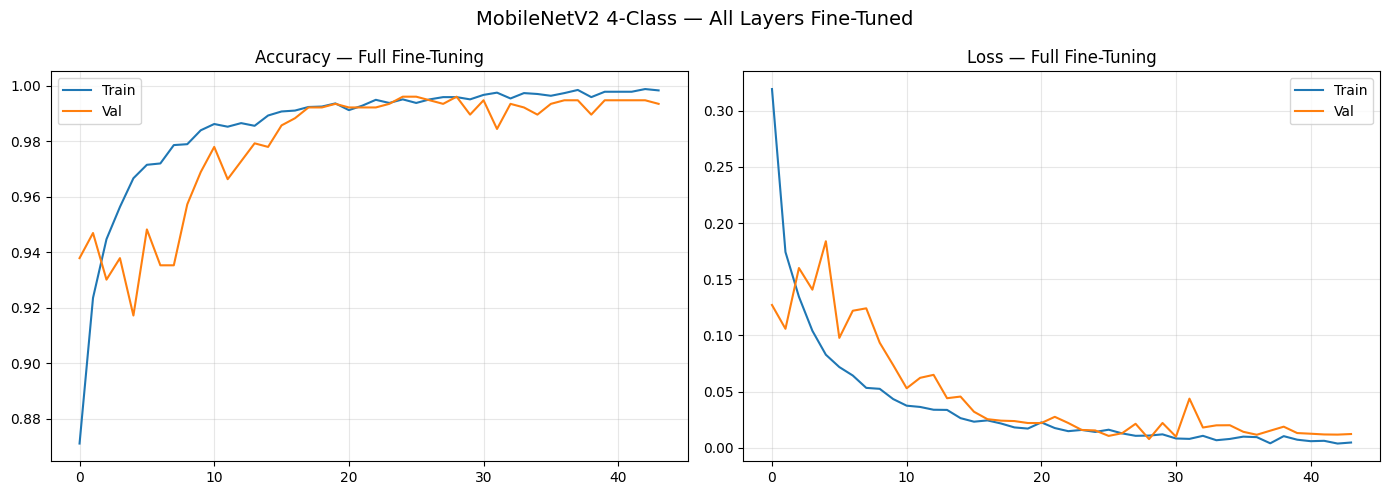

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_ft.history["accuracy"],     label="Train")
axes[0].plot(history_ft.history["val_accuracy"],  label="Val")
axes[0].set_title("Accuracy — Full Fine-Tuning")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_ft.history["loss"],     label="Train")
axes[1].plot(history_ft.history["val_loss"],  label="Val")
axes[1].set_title("Loss — Full Fine-Tuning")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle("MobileNetV2 4-Class — All Layers Fine-Tuned", fontsize=14)
plt.tight_layout(); plt.show()

---
## 8. Evaluate on Test Set

In [9]:
best_model = keras.models.load_model(BEST_FT)

y_pred_probs = best_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_labels

acc = accuracy_score(y_true, y_pred)
print(f"\nTest Accuracy: {acc:.4f}  ({acc*100:.2f}%)\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 257ms/step

Test Accuracy: 0.9948  (99.48%)

              precision    recall  f1-score   support

    Cracking       1.00      1.00      1.00       173
   Stringing       0.99      1.00      0.99       243
     Warping       1.00      1.00      1.00       169
   No_Defect       0.99      0.98      0.99       190

    accuracy                           0.99       775
   macro avg       1.00      1.00      1.00       775
weighted avg       0.99      0.99      0.99       775



---
## 9. Confusion Matrix

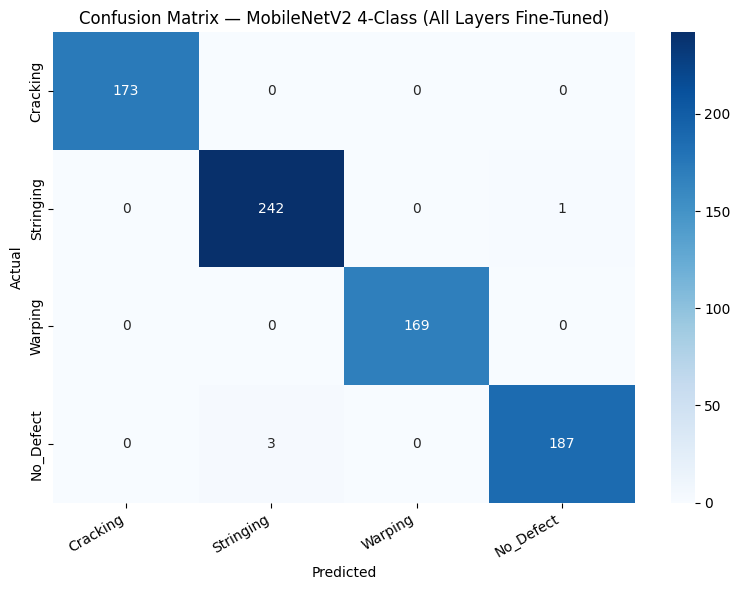

In [10]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — MobileNetV2 4-Class (All Layers Fine-Tuned)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

---
## 10. Save the Model

In [11]:
best_model.save("mobilenetv2_4class_alllayers_final.h5")
best_model.save("mobilenetv2_4class_alllayers_savedmodel")
print("✅ mobilenetv2_4class_alllayers_final.h5")
print("✅ mobilenetv2_4class_alllayers_savedmodel/")

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=mobilenetv2_4class_alllayers_savedmodel.